# Exercise 2 - Cameras and Lenses


## Introduction

The purpose of this exercise is to use Python to calculate camera and scene specific values.

## Learning Objectives

After completing this exercise, the student should be able to do the following:

- Create a Python function that uses the thin lens equation to compute either the focal length (f), where the rays are focused (b) or an object distance (g) when two of the other measurements are given



## Computing camera parameters

### Exercise 1

Explain how to calculate the angle $\theta$ when $a$ and $b$ is given
in the figure below. Calculate $\theta$ (in degrees) when
$a = 10$ and $b=3$ using the function `math.atan2()`. Remember to import `math` and find out what `atan2` does.

![Angle in triangel](figures/ArcTangens.png)

In [ ]:
#< START_SOLUTION 1>

import math

a, b = 10, 3
theta_rad = math.atan2(b, a)
theta_deg = theta_rad*180/math.pi

print(f"Angle (deg): {theta_deg}")
#< END_SOLUTION 1>

Angle (deg): 16.69924423399362


### Exercise 2

Create a Python function called `camera_b_distance`.

The function should accept two arguments, a focal length f and an
object distance g. It should return the distance from the lens to
where the rays are focused (b) (where the CCD should be placed)

The function should start like this:

```python
def camera_b_distance(f, g):
    """
    camera_b_distance returns the distance (b) where the CCD should be placed
    when the object distance (g) and the focal length (f) are given
    :param f: Focal length
    :param g: Object distance
    :return: b, the distance where the CCD should be placed
    """
```

It should be based on Gauss' lens equation:
$$\frac{1}{g} + \frac{1}{b} = \frac{1}{f}$$

You should decide if your function should calculate distances in mm or
in meters, but remember to be consistent!

Use your function to find out where the CCD should be placed when the
focal length is 15 mm and the object distance is 0.1, 1, 5, and 15
meters.

What happens to the place of the CCD when the object distance is increased?

In [ ]:
#< START_SOLUTION 2>

def camera_b_distance(f, g):
    """
    camera_b_distance returns the distance (b) where the CCD should be placed
    when the object distance (g) and the focal length (f) are given
    :param f: Focal length
    :param g: Object distance
    :return: b, the distance where the CCD should be placed
    """
    b = 1 / (f**(-1) - g**-(1))
    return b

In [ ]:
focal_distance = 15e-3 # meters
object_distances = [0.1, 1, 5, 15] # meters

for d in object_distances:
    val = camera_b_distance(focal_distance, d)
    print(f"Focal distance (m): {focal_distance} \t Object distance (m): {d} \t CCD place (m): {val}")
#< END_SOLUTION 2>

Focal distance (m): 0.015 	 Object distance (m): 0.1 	 CCD place (m): 0.01764705882352941
Focal distance (m): 0.015 	 Object distance (m): 1 	 CCD place (m): 0.015228426395939085
Focal distance (m): 0.015 	 Object distance (m): 5 	 CCD place (m): 0.015045135406218655
Focal distance (m): 0.015 	 Object distance (m): 15 	 CCD place (m): 0.015015015015015013


## Part 2: Two amateur metrologists and an experiment in subpixel precision


### Exercise 3

#< START_SOLUTION 3>
$$B = \frac{385}{2} \cdot 1.2 \cdot 10^{-6} \text{m} = 2.31\cdot 10^{-4} \text{m}$$
#< END_SOLUTION 3>

### Exercise 4

#< START_SOLUTION 4 >

$$\frac{b}{B} = \frac{g}{G} \leftrightarrow b = \frac{g\cdot B}{G} = \frac{2.9968 \text{m}  \cdot 2.31\cdot 10^{-4}}{\frac{0.290}{2}\text{m}} = 4.77\cdot 10^{-3}\text{m}$$
#< END_SOLUTION 4 >

### Exercise 5

#< START_SOLUTION 5>

$$h_m \times w_m = 3840\cdot 1.2\cdot 10^{-6} m \times 2160\cdot 1.2\cdot 10^{-6}m = 4.61\cdot 10^{-3} \text{m} \times 2.59\cdot 10^{-3}\text{m}$$

#< END_SOLUTION 5 >

### Exercise 6

#< START_SOLUTION 6 >
$$f_h = 2\tan^{-1}\left(\frac{\frac{w_m}{2}}{f}\right)\frac{180}{\pi} = 2\tan^{-1}(\frac{\frac{2.59}{2}\cdot 10^{-3}\text{m}}{6.8\cdot 10^{-3}m})\cdot \frac{180}{\pi} = 21.6^{\circ}$$
#< END_SOLUTION 6 >

### Exercise 7

#< START_SOLUTION 7 >
$$f_v = 2\tan^{-1}\left(\frac{\frac{h_m}{2}}{f}\right)\frac{180}{\pi} = 2\tan^{-1}(\frac{\frac{4.61}{2}\cdot 10^{-3}\text{m}}{6.8\cdot 10^{-3}m})\cdot \frac{180}{\pi} = 37.47^{\circ}$$

#< END_SOLUTION 7 >

### Exercise 8

#< START_SOLUTION 8 >
First calculate the image distance using the thin lens formula: 

$$\frac{1}{f}=\frac{1}{b}+\frac{1}{g}\leftrightarrow b = \frac{1}{\frac{1}{f}-\frac{1}{g}} = \frac{1}{\frac{1}{6.8\cdot 10^{-3}\text{m}} - \frac{1}{2.9968\text{m}}} = 6.82\cdot 10^{-3}\text{m}$$

And now use this quantity to calculate the height from Eq. 2.3:

$$B = \frac{bG}{g} = \frac{6.82\cdot 10^{-3}\text{m}\cdot 53.98\cdot 10^{-3}\text{m}}{2.9968\text{m}} = 1.22\cdot 10^{-4}\text{m}$$

Finally, relate this to the number of pixels using the side-length of a pixel: 

$$h_{pix} = \left\lceil \frac{B}{p} \right\rceil = \left\lceil \frac{1.22\cdot 10^{-4}\text{m}}{1.2\cdot 10^{-6}\text{m}}\right\rceil = \lceil 102.3 \rceil = 103$$

#< END_SOLUTION 8 >

### Exercise 9

#< START_SOLUTION 9 >
We have the equation 

$$B/p = 1 \rightarrow \frac{bG}{gp} = 1 \rightarrow G = \frac{g p}{b}$$ 

so the following computation yields the pixel dimension:

$$\frac{2.9968\text{m}\cdot 1.2\cdot 10^{-6}\text{m}}{6.82\cdot 10^{-3}\text{m}} = 5.28\cdot 10^{-4}\text{m}$$

And in general for the setting where $g\gg f$, we may additionally use $b\approx f$. The approximation $b\approx f$ holds because the working distance is much larger than the focal length. In this regime, the thin-lens camera behaves like a pinhole camera with an effective focal length. This is why calibration procedures estimate camera parameters directly in pixel units rather than attempting to recover physical lens properties. 

The result means that the camera setup from a single frame, disregarding noise and optic errors, is able to measure distances on a half millimeter scale. 
#< END_SOLUTION 9 >

### Exercise 10

#< START_SOLUTION 10 >
Measuring yields a width which is approximately: 

$$W_{pix} \approx 473-315 = 158$$

and a height: 

$$H_{pix} \approx 381-282 = 99$$ 

Which is quite close to the calculated theoretical value. Discrepancies may be caused by imprecise focal length, imprecised measured object distance and a slight rotation with respect to the sensor axes. In addition, the card is not in the optical center, which our calculations assume. **This is the exact reason why machine vision setups seldom rely on theoretical calculations, but rather use calibration, as you will see in later exercises**. 
#< END_SOLUTION 10 >

### Exercise 11

#< START_SOLUTION 11 >

the camera vectors are: 

$$\begin{pmatrix} -\frac{W_c}{2} \\ 0\\ Z \end{pmatrix}, \qquad \begin{pmatrix} \frac{W_c}{2} \\ 0\\ Z \end{pmatrix},\qquad \begin{pmatrix} 0 \\ -\frac{H_c}{2}\\ Z \end{pmatrix}, \qquad \begin{pmatrix} 0 \\ \frac{H_c}{2}\\ Z \end{pmatrix}$$

which in this case yields:

$$\begin{pmatrix} -4.33\cdot 10^{-2}\text{m} \\ 0\\ 2.9968\text{m} \end{pmatrix}, \qquad \begin{pmatrix} 4.33\cdot 10^{-2}\text{m} \\ 0\\ 2.9968\text{m} \end{pmatrix},\qquad \begin{pmatrix} 0 \\ -2.70\cdot 10^{-2}\\ 2.9968\text{m} \end{pmatrix}, \qquad \begin{pmatrix} 0 \\ 2.70\cdot 10^{-2}\\ 2.9968\text{m} \end{pmatrix}$$


#< END_SOLUTION 11 >

### Exercise 12

#< START_SOLUTION 12 >
We have $z=f=6.8\cdot 10^{-3}m$. 
We may use the similarity of triangles to calculate: 

$$x' = \frac{f}{WD}x_c = \frac{6.8\cdot 10^{-3}\text{m}}{2.9968\text{m}}x_c, y' = \frac{f}{WD} = \frac{6.8\cdot 10^{-3}\text{m}}{2.9968\text{m}}y_c$$

for each point. This yields:

$$\begin{bmatrix}
-9.81\cdot 10^{-5}\text{m} & 9.81\cdot 10^{-5}\text{m} & 0.00\text{m} & 0.00\text{m}\\
0.00 \text{m} & 0.00 \text{m} & -6.12\cdot 10^{-5}\text{m} & 6.12\cdot 10^{-5}\text{m}\\
6.8 \cdot 10^{-3}\text{m} & 6.8\cdot 10^{-3}\text{m} & 6.8\cdot 10^{-3}\text{m} & 6.8\cdot 10^{-3}\text{m}\\
\end{bmatrix}$$ 

#< END_SOLUTION 12 >

### Exercise 13

#< START_SOLUTION 13 >
First, calculate the physical width and height on the sensor: 

$$\Delta x = 9.81\cdot 10^{-05}\text{m}-(-9.81\cdot 10^{-05}\text{m})=19.6\cdot10^{-4}\text{m}, \Delta y = 6.12\cdot 10^{-5}\text{m}-(-6.12\cdot 10^{-5}\text{m})=1.22\cdot 10^{-4}\text{m}$$ 

and divide each by the pixel pitch: 

$$n_w = \frac{\Delta x}{p} = \frac{19.6\cdot10^{-4}\text{m}}{1.2\cdot 10^{-6}\text{m}} = 163.6, \qquad n_h = \frac{\Delta y}{p} = \frac{1.22\cdot 10^{-4}\text{m}}{1.2\cdot 10^{-6}\text{m}} = 102.1$$

#< END_SOLUTION 13 >

### Exercise 14

#< START_SOLUTION 14 >

The difference arises because Exercise 8 uses the full thin-lens equation, whereas Exercises 11–13 use a pinhole (triangulation) approximation in which the image distance is assumed to be equal to the focal length. Since the working distance is large compared to the focal length ($g>gg f$), the relative error introduced by this approximation is very small, but still present. 
If we used $b$ instead of $f$ for the imaging distance, we would recover exactly the same values. 

#< END_SOLUTION 14 >

### Exercise 15

#< START_SOLUTION 15 >
Now the two results are equivalent. This is because it is the same projective geometry; in essence, it is the same math, but written in two different coordinate frames. In 8 we compute the dimensions using lens-equations, i.e. we use a thin-lens model, whereas we in 11-13 use a pinhole camera. The thin-lens equation simply determines the image distance $b$, while triangulation describes how 3D points map to the image plane once $b$ is known. 

Although the thin-lens model is physically more detailed, it is rarely used in the machine vision industry because the image distance $b$ cannot be recovered from images alone. This is due to the fact that $b$ is fundamentally entangled with the unknown (or variable) object distance. As a result, $b$ is not an observable quantity in projective imaging. 

Computer vision therefore uses a pinhole model in which all internal camera geometry is absorbed into an effective focal length measured directly in pixel units. This directly translates to saying that lens thickness and internal structure are irrelevant for projective geometry, once the image is in focus and the working distance is large. 

#< END_SOLUTION 15 >

### Exercise 16


In [2]:
#< START_SOLUTION 16 >
import numpy as np 
def load_measurements(path, method="simple"):
    print(f"{path}/{method}/card_heights.csv")
    card_w = np.loadtxt(f"{path}/{method}/card_widths.csv",delimiter=",")
    paper_w = np.loadtxt(f"{path}/{method}/paper_widths.csv",delimiter=",")
    filenames = np.loadtxt(f"{path}/{method}/filenames.csv",delimiter=",",dtype=str)
    return {"card_w":card_w,"paper_w":paper_w, "filenames": filenames}

in_dir = f"data/measurements/"
METHOD="lstsq"
measurements = load_measurements(in_dir,METHOD)
np. set_printoptions(precision=6)
print(f"Example data of card widths: {measurements["card_w"]}")

#< END_SOLUTION 16 >

data/measurements//lstsq/card_heights.csv
Example data of card widths: [159. 158. 159. ... 158. 158. 158.]


### Exercise 17

In [3]:
#< START_SOLUTION 17 >
card_w = 85.60 #mm 
mm_per_pixel_w = (card_w/(measurements["card_w"].mean())) 

print(f"width mm/pixel resolution in object plane: {mm_per_pixel_w:.4f}")
#< END_SOLUTION 17 >

width mm/pixel resolution in object plane: 0.5393


### Exercise 18

In [5]:
#< START_SOLUTION 18 >
widths = measurements["paper_w"]
window_size = 10
J = 1
Ns = np.arange(window_size, len(widths), J)  # More points for smoother curve
# Calculate metrics correctly
width_means = []
width_moving_avg = [] # Moving average of mean, using <window_size> samples
width_sem = []  # Standard error of the mean
width_std_of_sample = []  # Sample standard deviation

for n in Ns:
    # Average pixel measurements
    width_slice = widths[:n]
    paper_width_pixels = widths[n]
    moving_avg = widths[n-window_size:n].mean()
    # mean_paper_width_pixels = widths[:n].mean()   
    # Apply calibration
    width_means.append(paper_width_pixels * mm_per_pixel_w)
    width_moving_avg.append(moving_avg * mm_per_pixel_w)
    width_std = (width_slice*mm_per_pixel_w).std(ddof=1) #ddof=1 because sample std
    width_std_of_sample.append(width_std)
    # Standard error of the mean = std / sqrt(n)
    width_sem.append(width_std / np.sqrt(n))

#< END_SOLUTION 18 >

### Exercise 19

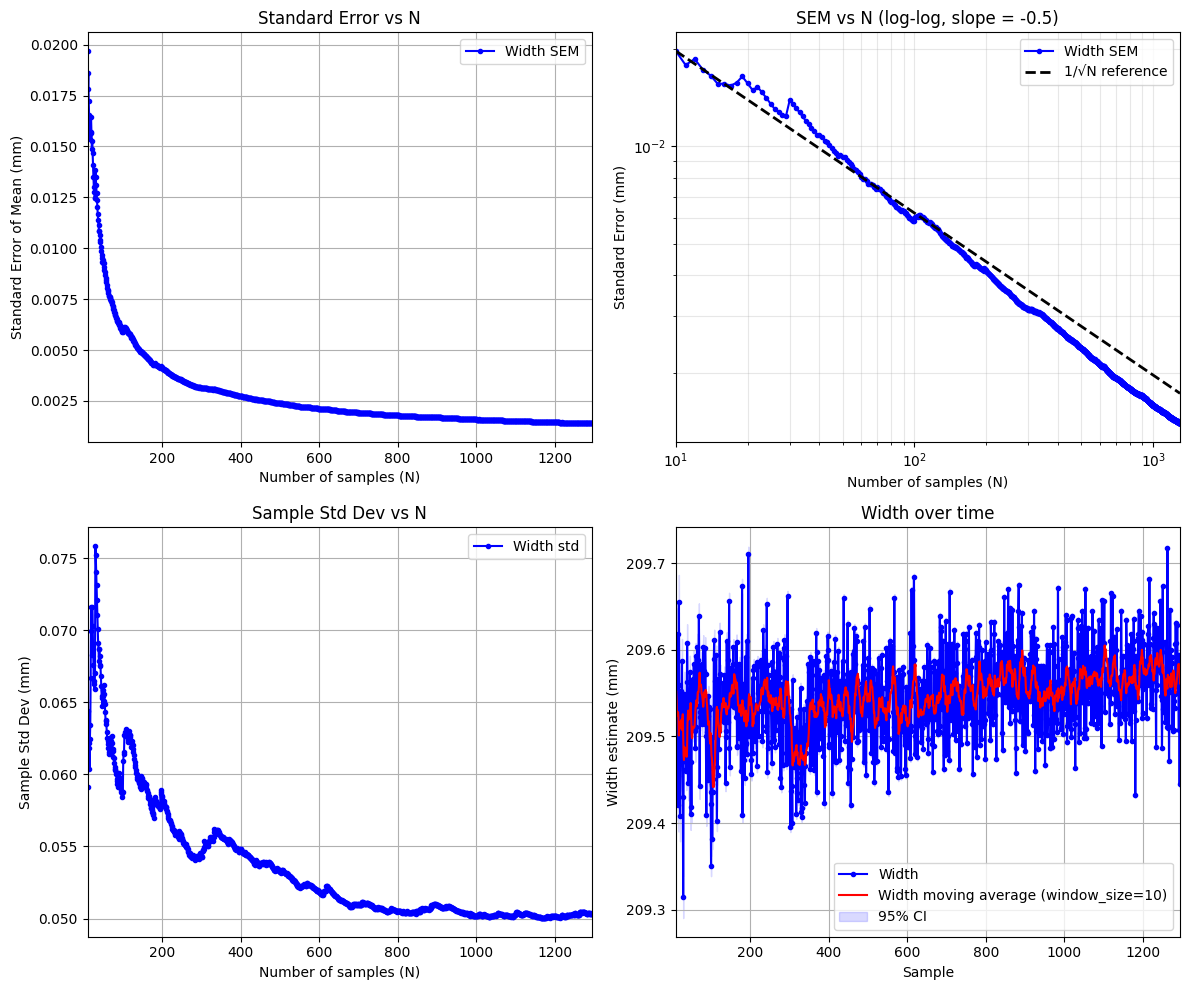


Individual measurement noise:
Final width estimate:  209.546 ± 0.001 mm


In [8]:
#< START_SOLUTION 19 >
import matplotlib.pyplot as plt 
# Create plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top left: Standard error of the mean vs N (should decrease as 1/√N)
axes[0, 0].plot(Ns, width_sem, 'b-', marker='o', markersize=3, label='Width SEM')
axes[0, 0].set_xlabel('Number of samples (N)')
axes[0, 0].set_ylabel('Standard Error of Mean (mm)')
axes[0, 0].set_title('Standard Error vs N')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Top right: Log-log plot of SEM (should have slope -0.5)
axes[0, 1].loglog(Ns, width_sem, 'b-', marker='o', markersize=3, label='Width SEM')
# Theoretical 1/√N line
theoretical = width_sem[0] * np.sqrt(Ns[0]) / np.sqrt(Ns)
axes[0, 1].loglog(Ns, theoretical, 'k--', linewidth=2, label='1/√N reference')

axes[0, 1].set_xlabel('Number of samples (N)')
axes[0, 1].set_ylabel('Standard Error (mm)')
axes[0, 1].set_title('SEM vs N (log-log, slope = -0.5)')
axes[0, 1].legend()
axes[0, 1].grid(True, which='both', alpha=0.3)

# Bottom left: Sample std (should be roughly constant)
axes[1, 0].plot(Ns, width_std_of_sample, 'b-', marker='o', markersize=3, label='Width std')
axes[1, 0].set_xlabel('Number of samples (N)')
axes[1, 0].set_ylabel('Sample Std Dev (mm)')
axes[1, 0].set_title('Sample Std Dev vs N')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Bottom right: Mean convergence
# axes[1, 1].plot(Ns, width_means, 'b-', marker='o', markersize=3, label='Width mean')
#add 95% confint
z_score = 1.96
# Convert lists to numpy arrays for vector math
w_means_arr = np.array(width_means)
w_mov_avg_arr = np.array(width_moving_avg)
w_sem_arr = np.array(width_sem)
# Width Plot
axes[1, 1].plot(Ns, w_means_arr, 'b', marker='o', markersize=3, label='Width')
axes[1, 1].plot(Ns, w_mov_avg_arr, 'r-', label=f'Width moving average (window_size={window_size})')
# Shade the 95% Confidence Interval (± 1.96 * SEM)
axes[1, 1].fill_between(Ns, 
                        w_means_arr - z_score * w_sem_arr, 
                        w_means_arr + z_score * w_sem_arr, 
                        color='b', alpha=0.15, label='95% CI')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Width estimate (mm)')
axes[1, 1].set_title('Width over time')
axes[1,1].ticklabel_format(useOffset=False)
axes[1, 1].legend()
axes[1, 1].grid(True)
for ax in axes.flatten():
    ax.set_xlim([Ns[0],Ns[-1]])

plt.tight_layout()
plt.show()

# Summary
print(f"\nIndividual measurement noise:")
w_phys = widths * mm_per_pixel_w
print(f"Final width estimate:  {w_phys.mean():.3f} ± {w_phys.std(ddof=1)/np.sqrt(len(w_phys)):.3f} mm")
#< END_SOLUTION 19 >

### Exercise 20

#< START_SOLUTION 20 >

- **The standard error** should in all cases decrease as $N$ increases. More specifically, when making a log-log plot, the slope should be -0.5 as we expect $\sigma(\tilde{X})\propto\frac{1}{\sqrt{N}}$. If this were not observed, some of the underlying assumptions are violated, and we can not necessarily rely on temporal averaging to improve precision. 
- **The sample standard deviation** should stabilize more and more as $N$ increases. It is a measure of our confidence in the estimator; if it does not converge, the underlying estimation procedure is not very robust or strong outliers are present, which directly will yield slower convergence of the estimator; as a result, more samples are to be collected or the imaging/estimation pipeline is to be re-done.
- **The means** should converge towards somewhere within the tolerance band of the paper dimensions, i.e. $210 \pm 2\text{mm}$ unless the paper is wrongly manufractured. If the measurements converge towards other values, there is bias present in the estimation. If the means do not converge, this could indicate drift, which could be caused by an unstable setup.  
- Taking a longer video will make our estimate have a lower and lower standard error (high precision), but it will not be accurate if systematic bias present or there is drift   
    
#< END_SOLUTION 20 >

### Exercise 21

To run the code below, you need to install the Python package: `statsmodels`.

#< START_SOLUTION 21 >

The assumed width-over-time plot indicates, that there is some correlated noise present. This is particularly evident from the moving average (red line), which seems to indicate some form of trend in the data. Only using visual inspection, it is therefore highly likely that the scene environment produces unforeseen measurement fluctuations, making it necessary to integrate this contribution out.

Can we form further conclusive evidence for this? We can start by running the following code:

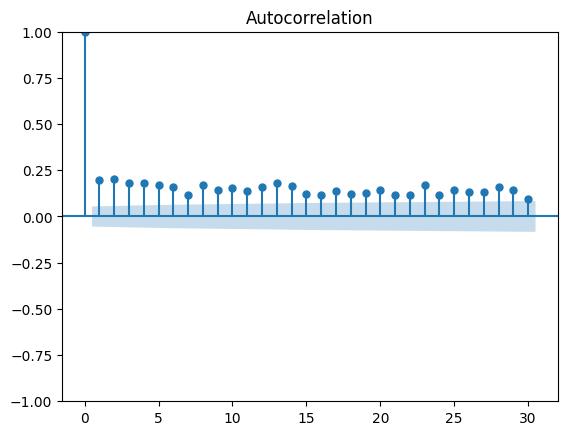

In [47]:
from statsmodels.graphics.tsaplots import plot_acf
fig = plot_acf(width_means, lags=30)

This figure gives conclusive evidence, that noise is correlated (lines, or "lags", after 0 would lie within the blue confidence band otherwise).

Inspecting the figure, there *may be* evidence to suggest that the noise is periodic. If so, this is likely produced by flickering from ambient lighting. This is however not conclusive. The likely cause of noise is either:

- Ambient lighting,
- Noise produced internally within camera (heat accumulation, inherent exposure adjustments produced by smartphone frame processing, etc.)

With the latter more likely.

To mitigate the noise, a suggestion could be to employ a very bright light source together with an industrial camera, which would decrease the effect of both.

#< END_SOLUTION 21>

### Exercise 22


In [ ]:
#< START_SOLUTION 22>
w_phys = measurements["paper_w"].mean()*mm_per_pixel_w
print(f"Estimated width of paper: {w_phys:.4f}")

NameError: name 'measurements' is not defined

We get $209.546\text{mm}$. Inspecting the width manually, we get between $209{-}210\text{mm}$, which aligns very well to our data estimate.


#< END_SOLUTION 22>

### Exercise 23

#< START_SOLUTION 23 >

Changing the experimental procedure. Without a proper machine vision configuration, there is bound to be some noise, which could be detrimental for certain tasks.

Taking a longer video isn't detrimental

#< END_SOLUTION 23 >

# Exam exercises

*Question 1: A company is making an automated system for fish inspection. They are using a camera with a CCD chip that measures 5.4 x 4.2 mm and that has a focal length of 10 mm. The camera takes photos that have dimensions 6480 x 5040 pixels and the camera is placed 110 cm from the fish, where a sharp image can be acquired of the fish. How many pixels wide is a fish that has a length of 40 cm?*


#< START_SOLUTION 24 >
- [x] 4364
- [ ] 4135
- [ ] 3213
- [ ] 5612
- [ ] 1872
- [ ] Do not know
#< END_SOLUTION 24 >



*Exam question 2: You have a camera with a focal length of 52 mm and a CCD chip of 8 mm x 6 mm. The image dimensions are 3200 x 2400 pixels. It can be assumed that b = f. From a distance of 10 cm you have taken a sharp picture of an eye with a completely round pupil. The image is thresholded such that only the pupil is visible. You find the area of the pupil to be 416248 pixels. What is the real diameter of the pupil given in millimeters?*

#< START_SOLUTION 25 >

- [ ] 4.2 millimeter
- [x] 3.5 millimeter
- [ ] 2.9 millimeter
- [ ] 3.8 millimeter
- [ ] 4.4 millimeter
- [ ] Do not know

#< END_SOLUTION 25 >


*Exam question 3: You have a camera with a field-of-view of 35◦ both horizontally and vertically. The cameras focal length is 20 mm and it can be assumed that f = b. What should the height of the CCD chip be, in order to take an image of the whole field-of-view?*

#< START_SOLUTION 26 >

- [ ] 8.2 mm
- [ ] 9.8 mm
- [ ] 13.7 mm
- [ ] 10.1 mm
- [x] 12.6 mm
- [ ] Do not know

#< END_SOLUTION 26 >
